In [1]:
import Pkg
Pkg.activate("../chebcoefs")
Pkg.instantiate()

  Activating project at `~/repos/WaveGreen2D/chebcoefs`


In [2]:
using CairoMakie
using FastChebInterp
using JLD2
using QuadGK
using StaticArrays
using WaveGreen2D.Chebyshev

In [4]:
# Tolerance is set by default to machine precision, but can be adjusted to the desired value.
# For a well chosen quadrature order, the maximum number of function evaluations does not go beyond 10³.
# For L₁ and L₂, especially close to the poles, the best quadrature order is between 24 and 34.
tol = eps()
imax = 1e3
qorder = 26


function mod_quadgk(f, a, b; rtol=sqrt(eps()), atol=0, maxevals=10^7, order=7)
    # Put 26 as the first try.
    qorder_vals = [[26, 25, 24]; collect(27:34)]
    
    if !(order in qorder_vals)
        pushfirst!(qorder_vals, order)
    end

    ∫f = err = nothing
    
    for qo in qorder_vals
        ∫f, err, count = quadgk_count(f, a, b; rtol=rtol, atol=atol, maxevals=maxevals, order=qo)
        if count < maxevals
            return ∫f, err
        end
    end

    @warn "Reached the maximum number of function evaluations" maxlog=1
    
    return ∫f, err
end


function L₁(x::AbstractVector{<:Real})
    A, B, C = x
    H = 10.0^C  # C = log₁₀H
    
    f(u) = (u + H) / (u - H - (u + H)*exp(-2u))
    g(u) = exp(-u*(2+B)) + exp(-u*(2-B))
    h(u) = cos(u*A)
    p(u) = (f(u) * g(u) * h(u) + exp(-u)) / u
    
    path = (0.0, H+im, H+1.0, Inf)
    
    y  = mod_quadgk(p, path[1], path[2]; rtol=tol, atol=tol, maxevals=imax, order=qorder)[1]
    y += mod_quadgk(p, path[2], path[3]; rtol=tol, atol=tol, maxevals=imax, order=qorder)[1]
    y += mod_quadgk(p, path[3], path[4]; rtol=tol, atol=tol, maxevals=imax)[1]
    
    return real(y)
end


function L₂(x::AbstractVector{<:Real})
    A, B, C = x
    H = 10.0^C  # C = log₁₀H

    f(u) = (u + H) / (u - H - (u + H)*exp(-2u))
    g(u) = (u + H)^2 / ((u - H)^2 - (u^2 - H^2)*exp(-2u))
    p(u) = exp(-u*(2+B))
    q(u) = exp(-u*(4-B))
    r(u) = cos(u*A)
    
    h(u) = (f(u)*p(u) + g(u)*q(u)) * r(u) / u
    
    path = (0.0, H+im, H+1.0, Inf)
    
    y  = mod_quadgk(h, path[1], path[2]; rtol=tol, atol=tol, maxevals=imax, order=qorder)[1]
    y += mod_quadgk(h, path[2], path[3]; rtol=tol, atol=tol, maxevals=imax, order=qorder)[1]
    y += mod_quadgk(h, path[3], path[4]; rtol=tol, atol=tol, maxevals=imax)[1]
    
    return real(y)
end


function generate_coefficients(L, n, lb, ub; tol=eps())
    x = chebpoints(n, lb, ub)
    c = chebinterp(L.(x), lb, ub; tol=tol)
    return c.coefs
end;

In [5]:
# The domains of L₁(A, B, C) and L₂(A, B, C) are split in three parts along the dimension C, where C = log₁₀H.
# The split was adjusted to make the number of coefficients in each domain approximately the same.

# Domains lower and upper bounds
L₁_lb = [
    SA[0.0, 0.0, -2.0],
    SA[0.0, 0.0, 0.12],
    SA[0.0, 0.0, 0.94],
]

L₁_ub = [
    SA[0.5, 1.0, 0.12],
    SA[0.5, 1.0, 0.94],
    SA[0.5, 1.0, 2.0],
]

L₂_lb = [
    SA[0.0, 0.0, -2.0],
    SA[0.0, 0.0, 0.11],
    SA[0.0, 0.0, 0.84],
]

L₂_ub = [
    SA[0.5, 2.0, 0.11],
    SA[0.5, 2.0, 0.84],
    SA[0.5, 2.0, 2.0],
]

# Polynomial order
L₁_n = [
    (14, 18, 39),
    (14, 19, 39),
    (16, 19, 39),
]

L₂_n = [
    (11, 18, 38),
    (13, 21, 38),
    (13, 21, 38),
];

In [6]:
L₁_series = Array{ChebyshevSeries{Float64, 3}}(undef, 3)
L₂_series = Array{ChebyshevSeries{Float64, 3}}(undef, 3)

for i in 1:3
    coefs₁ = generate_coefficients(L₁, L₁_n[i], L₁_lb[i], L₁_ub[i]; tol=tol)
    coefs₂ = generate_coefficients(L₂, L₂_n[i], L₂_lb[i], L₂_ub[i]; tol=tol)

    L₁_series[i] = ChebyshevSeries(coefs₁, L₁_lb[i], L₁_ub[i])
    L₂_series[i] = ChebyshevSeries(coefs₂, L₂_lb[i], L₂_ub[i])
end

L₁_cluster = ChebyshevCluster(L₁_series...)
L₂_cluster = ChebyshevCluster(L₂_series...)

jldsave("chebclusters.jld2"; L₁=L₁_cluster, L₂=L₂_cluster)

In [7]:
function plot_maxcoefs(L_cluster; cluster_name="L", filename="maxcoefs.svg")
    fig = Figure(size=(1200, 400))
    
    axes = [Axis(
            fig[1, m],
            yscale=log10,
            title=L"%$cluster_name \text{ subdomain } %$m",
            xlabel="Coefficient order",
            yticks=LogTicks(LinearTicks(5)),
            limits=(nothing, (1e-16, 1.0)),
        ) for m in 1:3
    ]
    
    # for ax in axes
    #     ylims!(ax, 1e-16, 1.0)
    # end
    
    for m in 2:3
        axes[m].yticklabelsvisible = false
        axes[m].yticksvisible = false
    end
    
    supertitle = Label(fig[0, :], "Larger coefficient (in absolute value) along each dimension", fontsize = 20)
    
    for m in 1:3
        coefs = L_cluster.series[m].coefs
        
        coefs_A = [maximum(abs.(coefs[i, :, :])) for i in 1:size(coefs, 1)]
        coefs_B = [maximum(abs.(coefs[:, j, :])) for j in 1:size(coefs, 2)]
        coefs_log₁₀H = [maximum(abs.(coefs[:, :, k])) for k in 1:size(coefs, 3)]
        
        lines!(axes[m], 1:size(coefs, 1), coefs_A, color=:red, linestyle=:dash, label=L"A")
        lines!(axes[m], 1:size(coefs, 2), coefs_B, color=:green, linestyle=:dot, label=L"B")
        lines!(axes[m], 1:size(coefs, 3), coefs_log₁₀H, color=:blue, linestyle=:solid, label=L"log_{10}H")
    end
    
    axislegend(axes[1])
    save(filename, fig)
    return fig
end;

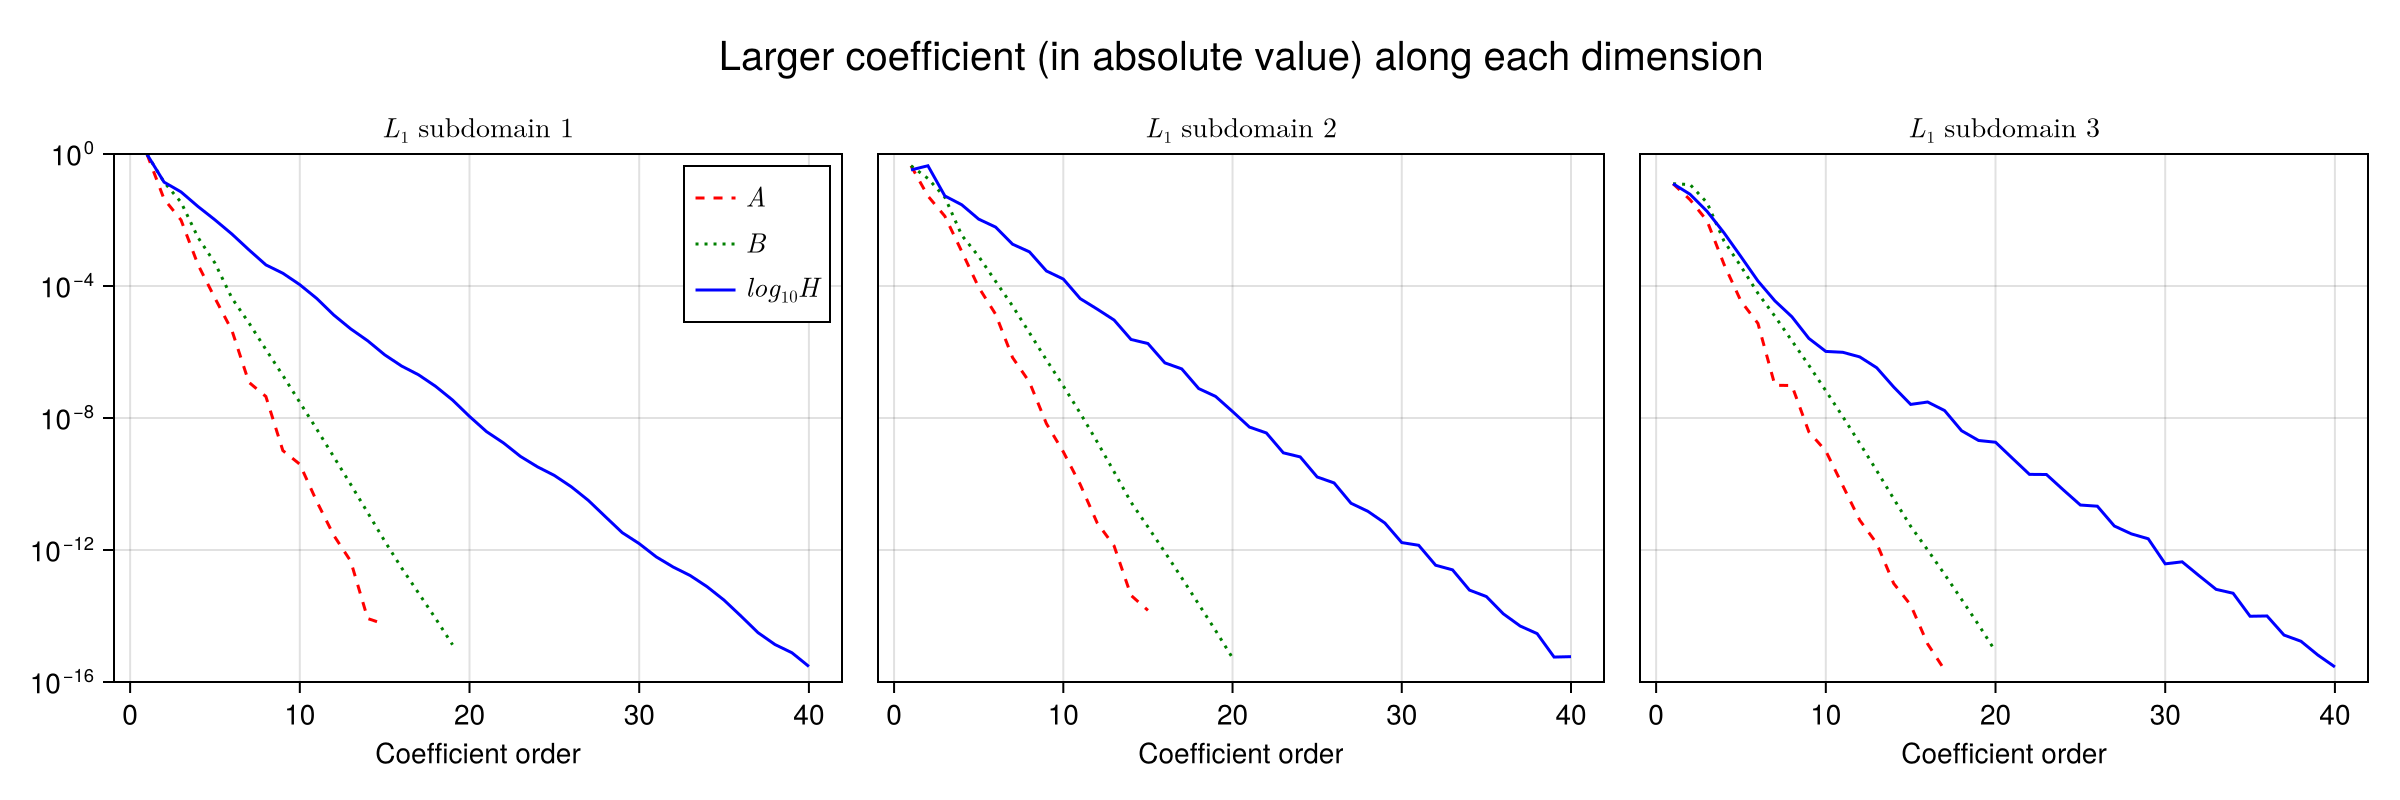

In [8]:
plot_maxcoefs(L₁_cluster; cluster_name="L_{1}", filename="l1_maxcoefs.svg")

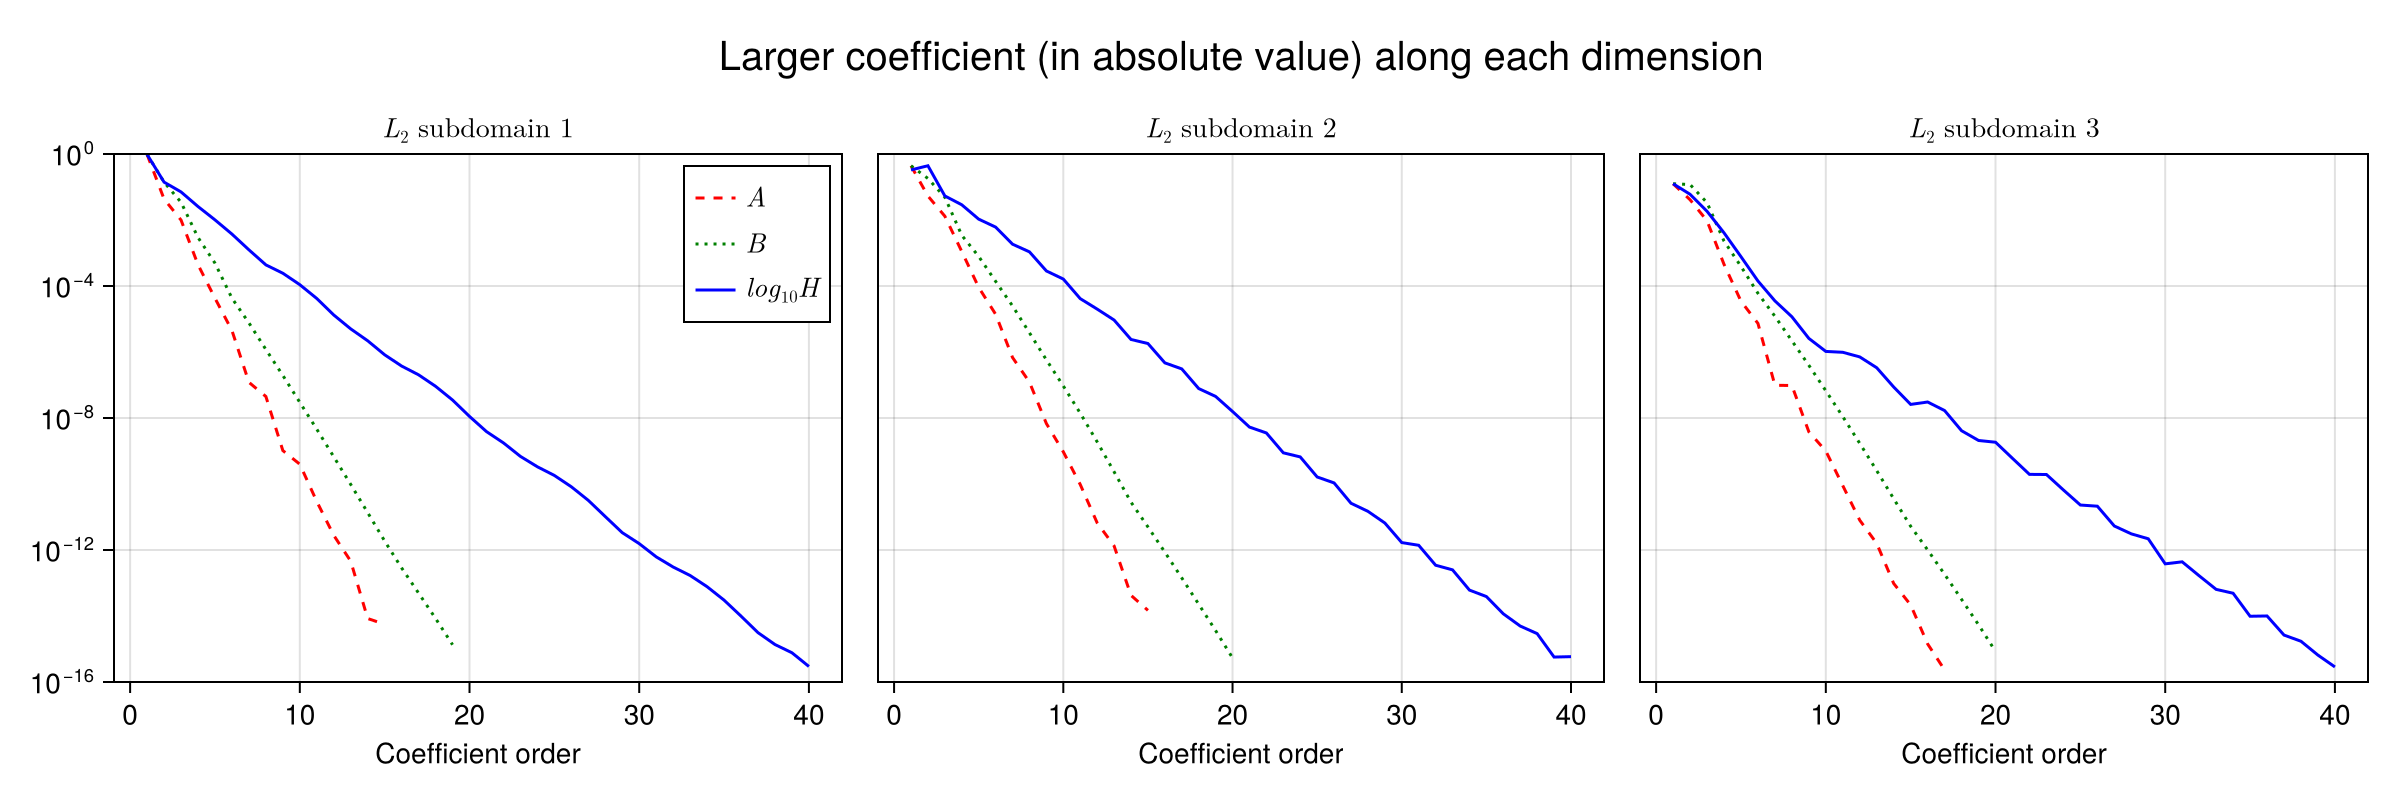

In [9]:
plot_maxcoefs(L₁_cluster; cluster_name="L_{2}", filename="l2_maxcoefs.svg")